# Importing and storing Data from Binance API

In [1]:
import time
import math
import requests
import pandas as pd
import numpy as np
from concurrent.futures import ThreadPoolExecutor, as_completed

In [2]:
def ms(ts: str) -> int:
    return int(pd.Timestamp(ts, tz="UTC").timestamp() * 1000)

def get_usdt_symbols(quote="USDT"):
    r = session.get(BASE + EXCHANGE_INFO, timeout=20)
    r.raise_for_status()
    data = r.json()["symbols"]
    symbols = [
        s["symbol"] for s in data
        if s["status"] == "TRADING"
        and s["quoteAsset"] == quote
        and s["isSpotTradingAllowed"]
    ]
    return symbols

def fetch_klines_one_call(symbol, start_ms=None, end_ms=None, limit=1000):
    params = {"symbol": symbol, "interval": "1d", "limit": limit}
    if start_ms is not None:
        params["startTime"] = start_ms
    if end_ms is not None:
        params["endTime"] = end_ms

    r = session.get(BASE + KLINES, params=params, timeout=20)
    # Basic retry for rate-limit / transient errors
    if r.status_code in (418, 429, 503):
        time.sleep(1.5)
        r = session.get(BASE + KLINES, params=params, timeout=20)
    r.raise_for_status()
    return r.json()

def fetch_daily_klines(symbol, start_date, end_date):
    start = ms(start_date)
    end = ms(end_date)
    out = []
    step = 86400000  

    while start < end:
        chunk = fetch_klines_one_call(symbol, start_ms=start, end_ms=end, limit=1000)
        if not chunk:
            break
        out.extend(chunk)
        # move to next day after last returned open_time
        start = chunk[-1][0] + step

        # gentle pacing (helps avoid rate limits when running many symbols)
        time.sleep(0.05)

    if not out:
        return pd.DataFrame()

    cols = [
        "open_time","open","high","low","close","volume",
        "close_time","quote_volume","num_trades",
        "taker_buy_base","taker_buy_quote","ignore"
    ]
    df = pd.DataFrame(out, columns=cols)
    df["crypto"] = symbol
    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms", utc=True)
    df["date"] = df["open_time"].dt.normalize().dt.tz_localize(None)

    for c in ["open","high","low","close","volume"]:
        df[c] = df[c].astype(float)
    df["log_return"] = np.log(df["close"]).diff()

    return df[["crypto","date", "close", "log_return", "open","high","low","volume"]]

def fetch_data(symbols, start_date, end_date, max_workers=6):
    """Parallel fetch across crypto (network-bound => threads are good)."""
    frames = []
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {
            ex.submit(fetch_daily_klines, sym, start_date, end_date): sym for sym in symbols
        }
        for fut in as_completed(futures):
            sym = futures[fut]
            try:
                df = fut.result()
                if not df.empty:
                    frames.append(df)
            except Exception as e:
                print(f"[WARN] {sym}: {e}")
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)

In [3]:
BASE = "https://api.binance.com"
KLINES = "/api/v3/klines"
EXCHANGE_INFO = "/api/v3/exchangeInfo"

session = requests.Session()
session.headers.update({"User-Agent": "research-notebook/1.0"})

symbols = [
    "BTCUSDT",
    "ETHUSDT",
    "BNBUSDT",
    "ADAUSDT",
    "XRPUSDT",
    "LTCUSDT",
    "BCHUSDT",
    "LINKUSDT"
]

df = fetch_data(symbols, "2020-01-01", "2025-12-31", max_workers=6) # 1 Jan 2020 to 31 Dec 2025
df.head()

,crypto,date,close,log_return,open,high,low,volume
0,LTCUSDT,2020-01-01,41.62,NaN,41.29,42.08,41.16,110044.87445
1,LTCUSDT,2020-01-02,39.43,-0.054054,41.58,41.74,39.17,194486.21570
2,LTCUSDT,2020-01-03,42.23,0.068604,39.44,42.39,38.77,426771.00676
3,LTCUSDT,2020-01-04,42.78,0.012940,42.23,42.90,41.77,248814.62818
4,LTCUSDT,2020-01-05,43.30,0.012082,42.79,44.61,42.60,291964.84958


In [4]:
df = df.sort_values(["crypto", "date"]).reset_index(drop=True)

n = 14  # lookback window for technical indicators

df["target_7d"] = (
    df.groupby("crypto")["log_return"]
      .rolling(7)
      .sum()
      .shift(-7)
      .reset_index(level=0, drop=True)
)

df["vol_30"] = (
    df.groupby("crypto")["log_return"]
      .rolling(30)
      .std()
      .reset_index(level=0, drop=True)
)

df["sma"] = (
    df.groupby("crypto")["close"]
      .transform(lambda x: x.rolling(n).mean())
)

df["ema"] = (
    df.groupby("crypto")["close"]
      .transform(lambda x: x.ewm(span=n, adjust=False).mean())
)

# Momentum (M) = C_t - C_{t-n}
df["momentum"] = (
    df.groupby("crypto")["close"]
      .transform(lambda x: x - x.shift(n))
)

# Typical Price = (High + Low + Close) / 3
df["tp"] = (df["high"] + df["low"] + df["close"]) / 3

# rolling mean of typical price
tp_sma = (
    df.groupby("crypto")["tp"]
      .transform(lambda x: x.rolling(n).mean())
)

# mean absolute deviation around rolling TP mean
tp_mad = (
    df.groupby("crypto")["tp"]
      .transform(lambda x: x.rolling(n).apply(
          lambda w: np.mean(np.abs(w - np.mean(w))), raw=True
      ))
)

df["cci"] = (df["tp"] - tp_sma) / (0.015 * tp_mad)
df.drop(columns=["tp"], inplace=True)

In [5]:
df_clean = df.dropna().reset_index(drop=True)
df_clean.head()

,crypto,date,close,log_return,open,high,low,volume,target_7d,vol_30,sma,ema,momentum,cci
0,ADAUSDT,2020-01-31,0.05390,-0.040718,0.05614,0.05680,0.05215,433767507.0,0.105045,0.045798,0.047334,0.048151,0.00900,122.762807
1,ADAUSDT,2020-02-01,0.05610,0.040005,0.05390,0.05723,0.05312,316991127.7,0.067542,0.045369,0.048134,0.049210,0.01121,111.792212
2,ADAUSDT,2020-02-02,0.05570,-0.007156,0.05608,0.05870,0.05489,534062511.4,0.105217,0.045313,0.049113,0.050076,0.01370,102.698809
3,ADAUSDT,2020-02-03,0.05696,0.022369,0.05572,0.05785,0.05528,293324470.9,0.056817,0.045275,0.050054,0.050994,0.01318,90.374711
4,ADAUSDT,2020-02-04,0.05601,-0.016819,0.05698,0.05788,0.05395,290866580.7,0.123145,0.045664,0.050768,0.051662,0.00999,70.369672


In [6]:
df_clean["crypto"].value_counts()

crypto
ADAUSDT     2155
BCHUSDT     2155
BNBUSDT     2155
BTCUSDT     2155
ETHUSDT     2155
LINKUSDT    2155
LTCUSDT     2155
XRPUSDT     2155
Name: count, dtype: int64

In [7]:
# train-test split
train_df = df_clean[df_clean["date"] < "2024-01-01"].copy() # 2020-2023 data
val_df   = df_clean[(df_clean["date"] >= "2024-01-01") & (df_clean["date"] < "2025-01-01")].copy() # 2024 data
test_df  = df_clean[df_clean["date"] >= "2025-01-01"].copy() # 2025

## EDA

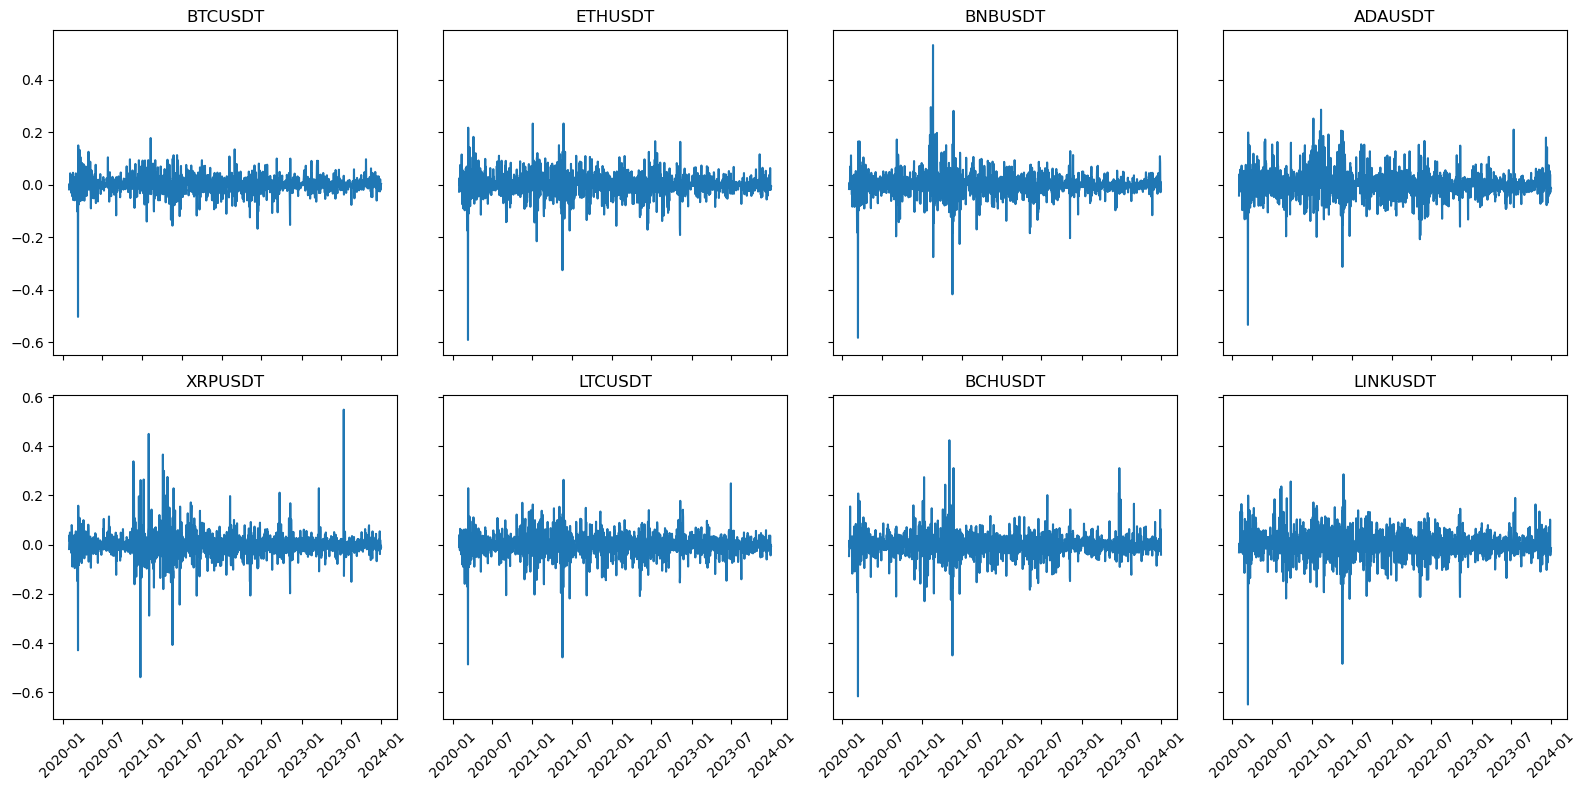

In [8]:
import matplotlib.pyplot as plt

num_sym = len(symbols)
fig, axs = plt.subplots(2, 4, figsize=(16, 8), sharex="col", sharey="row")

for i in range(num_sym):
    sym_dat = train_df[train_df["crypto"] == symbols[i]].sort_values("date")
    row_num = i // 4
    col_num = i % 4
    
    axs[row_num, col_num].plot(sym_dat["date"], sym_dat["log_return"])
    axs[row_num, col_num].set_title(symbols[i])
    
    # rotate x-axis labels
    axs[row_num, col_num].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [9]:
# stationarity test
from statsmodels.tsa.stattools import adfuller

results = []

for crypto, g in train_df.groupby("crypto"):
    
    # ensure correct time ordering
    series = g.sort_values("date")["log_return"].dropna()
    
    adf_stat, p_value, lags, n_obs, crit_vals, _ = adfuller(series, autolag="AIC")
    
    results.append({
        "crypto": crypto,
        "n_obs": n_obs,
        "adf_stat": adf_stat,
        "p_value": p_value,
        "1%_crit": crit_vals["1%"],
        "5%_crit": crit_vals["5%"],
        "10%_crit": crit_vals["10%"],
        "stationary_5pct": p_value < 0.05
    })

adf_results = pd.DataFrame(results).sort_values("crypto").reset_index(drop=True)

print(adf_results)

     crypto  n_obs   adf_stat       p_value   1%_crit   5%_crit  10%_crit  \
0   ADAUSDT   1422 -11.467985  5.352573e-21 -3.434957 -2.863575 -2.567853   
1   BCHUSDT   1411  -8.441094  1.762396e-13 -3.434993 -2.863591 -2.567862   
2   BNBUSDT   1417  -9.209222  1.907741e-15 -3.434973 -2.863582 -2.567857   
3   BTCUSDT   1427 -17.660291  3.684854e-30 -3.434941 -2.863568 -2.567849   
4   ETHUSDT   1421 -11.425050  6.727299e-21 -3.434960 -2.863576 -2.567854   
5  LINKUSDT   1426 -17.381652  5.068811e-30 -3.434944 -2.863569 -2.567850   
6   LTCUSDT   1427 -18.384603  2.206240e-30 -3.434941 -2.863568 -2.567849   
7   XRPUSDT   1430 -40.318360  0.000000e+00 -3.434931 -2.863563 -2.567847   

   stationary_5pct  
0             True  
1             True  
2             True  
3             True  
4             True  
5             True  
6             True  
7             True  


## Save data

In [10]:
fn = "outputs/data/binance_data_raw.csv"
df_clean.to_csv(fn)

## Add regime label

In [11]:
window = 50

def compute_rolling_zscore(df, past_df=None, window=100):
    """
    df: current dataframe (train/val/test)
    past_df: previous data to include for rolling calculations
    """
    if past_df is not None:
        # concatenate past data to maintain continuity
        df_full = pd.concat([past_df, df])
    else:
        df_full = df.copy()
    
    # compute rolling stats per crypto
    df_full["vol_mean"] = (
        df_full.groupby("crypto")["vol_30"]
        .transform(lambda x: x.rolling(window, min_periods=1).mean())
    )
    
    df_full["vol_std"] = (
        df_full.groupby("crypto")["vol_30"]
        .transform(lambda x: x.rolling(window, min_periods=1).std())
    )
    
    df_full["zscore"] = (df_full["vol_30"] - df_full["vol_mean"]) / df_full["vol_std"]
    df_full["regime_label"] = (df_full["zscore"] > 1).astype(int)
    
    # return only the rows of df (exclude past_df)
    if past_df is not None:
        return df_full.iloc[len(past_df):]
    else:
        return df_full

# Usage
train_df = compute_rolling_zscore(train_df, window=window)
val_df   = compute_rolling_zscore(val_df, past_df=train_df, window=window)
test_df  = compute_rolling_zscore(test_df, past_df=pd.concat([train_df, val_df]), window=window)

In [12]:
print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

Train: (11448, 18)
Val: (2928, 18)
Test: (2864, 18)


In [13]:
print("Val:", val_df["date"].min(), val_df["date"].max())

Val: 2024-01-01 00:00:00 2024-12-31 00:00:00


In [14]:
print("Test:", test_df["date"].min(), test_df["date"].max())

Test: 2025-01-01 00:00:00 2025-12-24 00:00:00


In [15]:
train_df.to_csv("outputs/data/train_df.csv", index=False)
val_df.to_csv("outputs/data/val_df.csv", index=False)
test_df.to_csv("outputs/data/test_df.csv", index=False)